Stratospheric ozone burdens

In [1]:
## use env cmipv2, because i need xgcm to do some vertical regridding. 

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
#import seaborn as sns
from xgcm import Grid
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, spatial_mean, set_time_to_center_of_bounds, yearly_timeseries

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors, model_names, lat_band_dict, UKESM_ARISE_run_IDs, UKESM_ARISE_run_dict, CESM_ARISE_run_IDs

In [3]:
def seasonal_time_slice(ds, start_yr_str='2050', end_yr_str='2069'):
    ds = ds.sel(time=slice(start_yr_str, end_yr_str)).groupby('time.month').mean(dim='time')
    return ds

In [4]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_O3_13_UK = seasonal_time_slice(get_ds(run = 'u-dm204dn587', var='o3_mmr', table='AERmon', zonal_mean=True))
ds_O3_15_UK = seasonal_time_slice(get_ds(run = 'u-dn760', var='o3_mmr', table='AERmon', zonal_mean=True))

#ds_O3_13_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Ozone/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.O3.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'}))#.sel(lev=slice(None, None, -1))
#ds_O3_15_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Ozone/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.O3.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'}))#.sel(lev=slice(None, None, -1))

# use CESM data which I have already vertically regridded onto Z3 variable#
ds_O3_13_CE = seasonal_time_slice(xr.open_dataset(path_archive+'/CESM_data/Ozone_Z/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.O3_Z3.203501-206912.nc'))#.sel(lev=slice(None, None, -1))
ds_O3_15_CE = seasonal_time_slice(xr.open_dataset(path_archive+'/CESM_data/Ozone_Z/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.O3_Z3.203501-206912.nc'))#.sel(lev=slice(None, None, -1))

ds_O3_13_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/O3/O3.polar.mip.e3sm.01.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_O3_15_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/O3/O3.polar.mip.e3sm.04.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)

In [5]:
## also regrid the UKESM HiLLA data onto the same Z3 levels as the subsequent ssp data. 
## Note that strictly altitude and geopotential height are not the same, but the difference is ~1% at these alts (only really matters in very high altitude in the tropics)
target_Z_levels = np.linspace(0, 30000, 50) # only need up to e.g. 30km
ds_O3_13_UK = ds_O3_13_UK.rename({'altitude':'Z3', 'o3_mmr':'O3'})
grid = Grid(ds_O3_13_UK, coords={'Z3': {'center': 'atmosphere_hybrid_height_coordinate_1'},}, periodic=False)
ds_O3_13_UK_on_Z = grid.transform(ds_O3_13_UK.O3, 'Z3', target_Z_levels, target_data=ds_O3_13_UK.Z3, method='linear', mask_edges=False)

ds_O3_15_UK = ds_O3_15_UK.rename({'altitude':'Z3', 'o3_mmr':'O3'})
grid = Grid(ds_O3_15_UK, coords={'Z3': {'center': 'atmosphere_hybrid_height_coordinate_1'},}, periodic=False)
ds_O3_15_UK_on_Z = grid.transform(ds_O3_15_UK.O3, 'Z3', target_Z_levels, target_data=ds_O3_15_UK.Z3, method='linear', mask_edges=False)


In [6]:
### for CESM and E3SM, also read in the Z3 data

#ds_Z3_13_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Z3/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.Z3_zm.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'})).load()#.sel(lev=slice(None, None, -1))
#ds_Z3_15_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Z3/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.Z3_zm.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'})).load()#.sel(lev=slice(None, None, -1))

ds_Z3_13_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3/Z3.polar.mip.e3sm.01.nc').rename({'lat':'latitude'}).mean('lon').load()
ds_Z3_15_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3/Z3.polar.mip.e3sm.04.nc').rename({'lat':'latitude'}).mean('lon').load()

In [7]:

## combine into a dict
HiLLA_O3_data = {'UKESM':{'13km': ds_O3_13_UK_on_Z.to_dataset(name='O3'), 
                          '15km': ds_O3_15_UK_on_Z.to_dataset(name='O3')}, 
                 'CESM': {'13km': ds_O3_13_CE['O3'].to_dataset(name='O3'),
                          '15km': ds_O3_15_CE['O3'].to_dataset(name='O3')}, 
                 'E3SM': {'13km': xr.merge([ds_O3_13_E3['O3'].to_dataset(name='O3'), ds_Z3_13_E3['Z3'].to_dataset(name='Z3')]),
                          '15km': xr.merge([ds_O3_15_E3['O3'].to_dataset(name='O3'), ds_Z3_15_E3['Z3'].to_dataset(name='Z3')])}}

In [8]:
## repeat the above to get the ssp245 reference case

ds_ssp245_O3_UK = seasonal_time_slice(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='o3', members=['r1i1p1f2'], 
                              table='AERmonZ', grid='gnz')).mean(['Ensemble_member']).rename({'y':'latitude'}) # note this is already a zonal mean (AERmonZ table)

ds_ssp245_Z3_UK = seasonal_time_slice(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='zg', members=['r1i1p1f2'], 
                              table='AERmonZ', grid='gnz')).mean(['Ensemble_member']).rename({'y':'latitude'}) # note this is already a zonal mean (AERmonZ table)

ds_ssp245_O3_CE = seasonal_time_slice(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='o3', members=['r1i1p1f1'], 
                              table='Amon', grid='gn')).mean(['x', 'Ensemble_member']).rename({'y':'latitude'})

ds_ssp245_Z3_CE = seasonal_time_slice(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='zg', members=['r1i1p1f1'], 
                              table='Amon', grid='gn')).mean(['x', 'Ensemble_member']).rename({'y':'latitude'})

ds_ssp245_O3_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/O3/O3.polar.mip.e3sm.control.nc').mean('lon').rename({'lat':'latitude'}).load() # already took the time slice for e3sm before regridding
ds_ssp245_Z3_E3 = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3/Z3.polar.mip.e3sm.control.nc').mean('lon').rename({'lat':'latitude'}).load() # already took the time slice for e3sm before regridding


In [9]:
ds_ssp245_UK = xr.merge([ds_ssp245_O3_UK['o3'].to_dataset(name='O3'), ds_ssp245_Z3_UK['zg'].to_dataset(name='Z3')]).load()
ds_ssp245_CE = xr.merge([ds_ssp245_O3_CE['o3'].to_dataset(name='O3'), ds_ssp245_Z3_CE['zg'].to_dataset(name='Z3')]).load()


In [10]:
## for UKESM ssp245, convert from mol fraction to mass-mixing ratio:

## VMR = (28.9644 / 47.9982) * MMR
## MMR = (47.9982 / 28.9644) * VMR
conversion_VMR_to_MMR = 47.9982/28.9644
ds_ssp245_UK['O3'] = ds_ssp245_UK['O3']*conversion_VMR_to_MMR

In [11]:
## regrid the UKESM and CESM ssp245 data in the vertical, to match the hilla cases
## we use xgcm for this, as in the "Regrid_CESM_vertical.ipynb" notebook in this folder
#target_Z_levels = np.linspace(0, 30000, 50) # only need up to e.g. 30km
grid = Grid(ds_ssp245_UK, coords={'Z3': {'center': 'plev'},}, periodic=False)
ds_ssp245_UK_on_Z = grid.transform(ds_ssp245_UK.O3, 'Z3', target_Z_levels, target_data=ds_ssp245_UK.Z3, method='linear', mask_edges=False)

#target_Z_levels = np.linspace(0, 30000, 30) # only need up to e.g. 30km
grid = Grid(ds_ssp245_CE, coords={'Z3': {'center': 'plev'},}, periodic=False)
ds_ssp245_CE_on_Z = grid.transform(ds_ssp245_CE.O3, 'Z3', target_Z_levels, target_data=ds_ssp245_CE.Z3, method='linear', mask_edges=False)

In [12]:


SSP245_data = {'UKESM':ds_ssp245_UK_on_Z.to_dataset(name='O3'),
               'CESM':ds_ssp245_CE_on_Z.to_dataset(name='O3'),
               'E3SM':xr.merge([ds_ssp245_O3_E3['O3'].to_dataset(name='O3'), ds_ssp245_Z3_E3['Z3'].to_dataset(name='Z3')])}


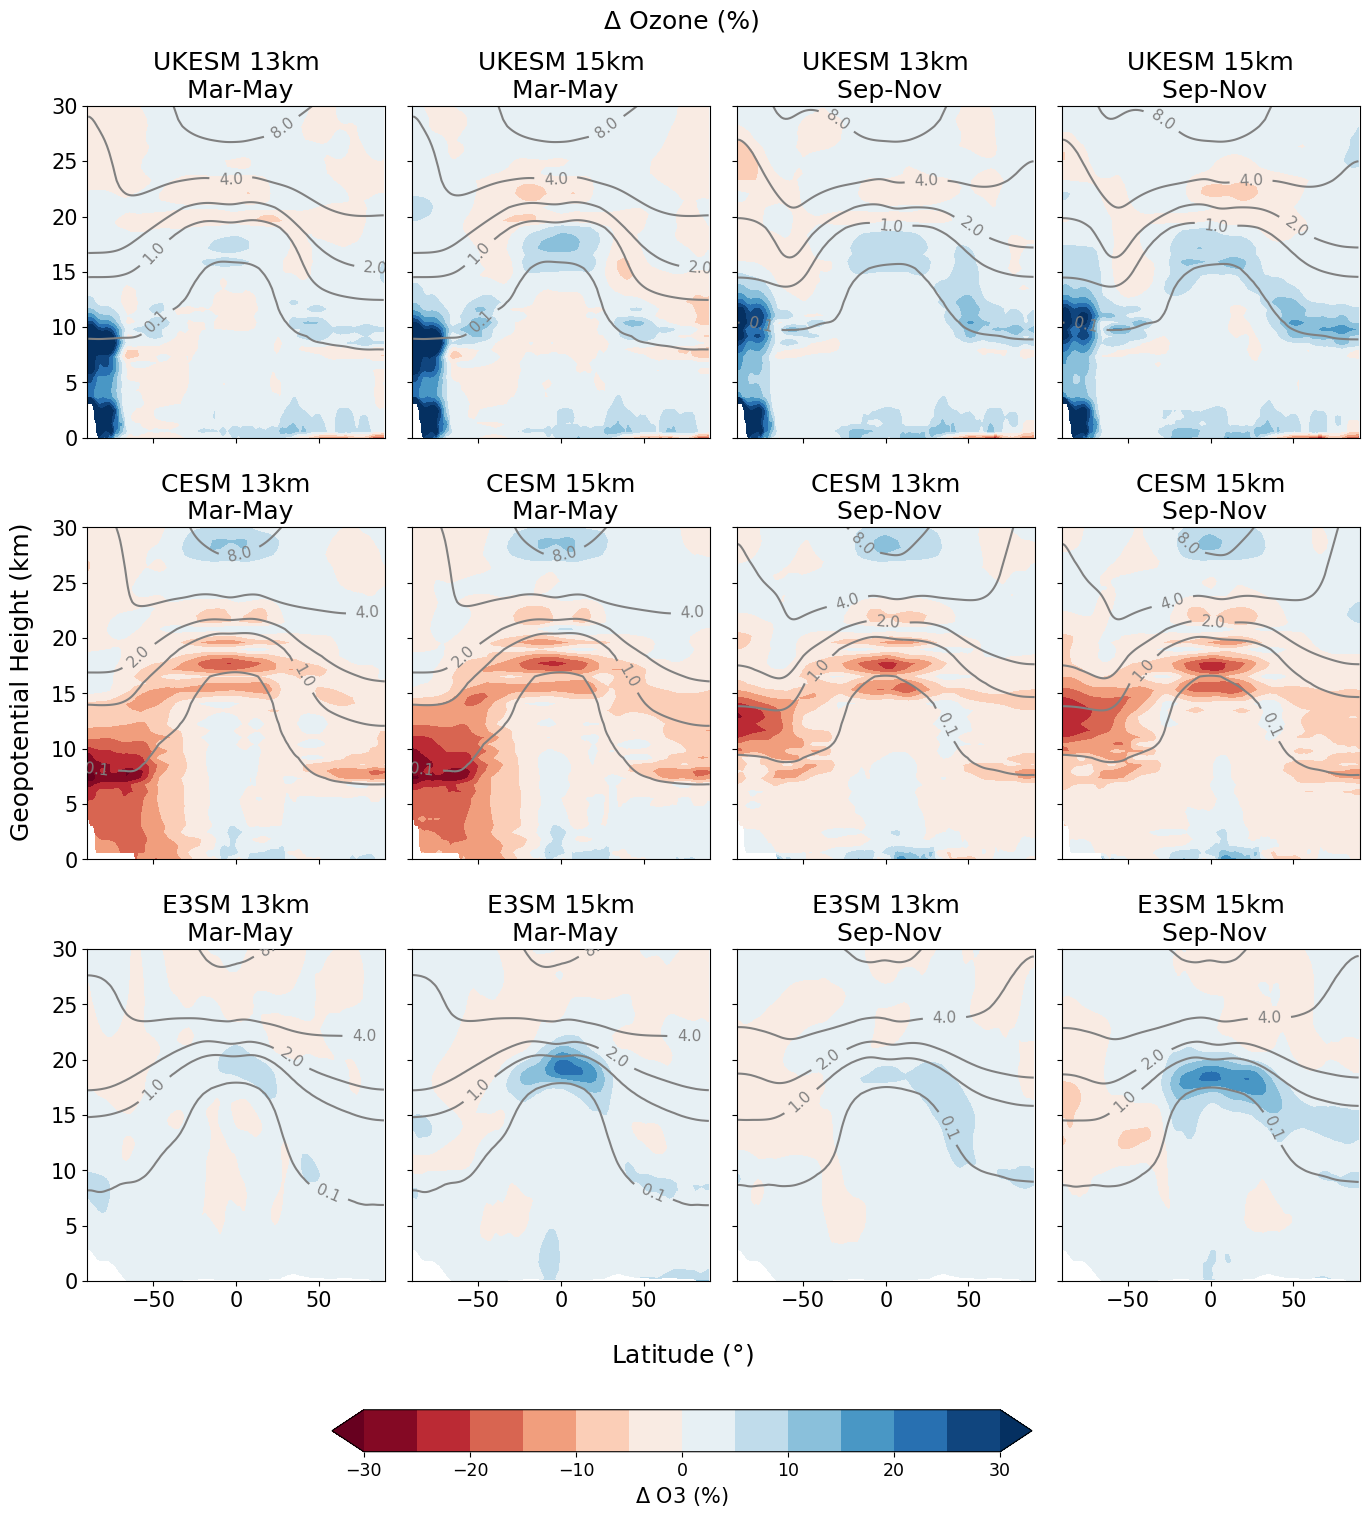

In [13]:
### PLOT

seasons = {'Mar-May': [2, 3, 4], 'Sep-Nov': [8, 9, 10]} # note isel not sel, so 0=Jan, 1=Feb etc.
fig, axs = plt.subplots(3, 4, figsize=(14, 14), sharey=True, sharex=True)


i=0
for model in ['UKESM', 'CESM', 'E3SM']:
    for season in list(seasons.keys()):
        for alt in ['13km', '15km']:
            ax = axs.flatten()[i]
            ds = HiLLA_O3_data[model][alt]
            ds_ref = SSP245_data[model]
            ds['O3_delta_perc'] = 100*(ds['O3'] - ds_ref['O3'])/ds_ref['O3']
            ds = ds.isel(month=seasons[season]).mean('month')
            ds_ref = ds_ref.isel(month=seasons[season]).mean('month')

            
            if model in ['UKESM', 'CESM']:
                lats, Z3s = np.meshgrid(ds['latitude'].values, 0.001*ds['Z3'].values)
                O3_delta_perc_values = ds['O3_delta_perc'].values.T
                O3_background_values = ds_ref['O3'].values.T
            elif model == 'E3SM':
                lats, _ = np.meshgrid(ds['latitude'].values, ds['lev'].values)
                # Y-axis: Geopotential Height (Z3)
                Z3s = 0.001*ds['Z3'].values
                # Z (Contour Data): O3_delta_perc
                O3_delta_perc_values = ds['O3_delta_perc'].values
                O3_background_values = ds_ref['O3'].values
            
            # convert back to molar fraction for UKESM
            if model == 'UKESM':
                O3_background_values = O3_background_values/conversion_VMR_to_MMR
                
            # Plot using contourf: X=lat_2d, Y=Z3_values, Z=O3_delta_perc_values
            # Use a diverging colormap since O3_delta_perc represents a delta/change
            # Set vmin/vmax to be symmetric around zero
            max_abs = np.nanmax(np.abs(O3_delta_perc_values))
            levels = np.linspace(-30, 30, 13)
    
            contour = ax.contourf(
                lats,
                Z3s,
                O3_delta_perc_values,
                levels=levels,
                cmap='RdBu', # Red-Blue reversed diverging colormap
                extend='both'
            )

            lines = ax.contour(
                lats,
                Z3s,
                1E6*O3_background_values,
                #levels=np.arange(0, 10, 1),
                levels=[0.1, 1, 2, 4, 8],
                colors='gray'#cmap='RdBu', # Red-Blue reversed diverging colormap
                #extend='both'
            )
            ax.clabel(lines, fontsize=11)
            ax.set_title('{m} {a}\n {s}'.format(m=model, a=alt, s=season))
            ax.set_ylim(0, 30)  # Set y-axis limits to focus on lower altitudes
            i=i+1


cbar_ax1 = fig.add_axes([0.25, -0.05, 0.5, 0.03])
cbar1 = fig.colorbar(contour, cax=cbar_ax1, orientation='horizontal', label='\u0394 O3 ($\%$)')
cbar1.ax.tick_params(labelsize='small')


fig.supylabel('Geopotential Height (km)')
fig.supxlabel('Latitude ($\degree$)')
fig.suptitle('\u0394 Ozone (%)')
plt.tight_layout()
plt.savefig('Figures/Ozone_overview.jpg', dpi=350, bbox_inches='tight')

In [14]:
### get all the standard deviations too, for a repeat plot with sig shading

In [15]:
ds_O3_13_UK_std = get_ds(run = 'u-dm204dn587', var='o3_mmr', table='AERmon', zonal_mean=True).sel(time=slice('2050', '2069')).groupby('time.season').std(['time'])
ds_O3_15_UK_std = get_ds(run = 'u-dn760', var='o3_mmr', table='AERmon', zonal_mean=True).sel(time=slice('2050', '2069')).groupby('time.season').std(['time'])

In [16]:
## 


# use CESM data which I have already vertically regridded onto Z3 variable#
ds_O3_13_CE_std = xr.open_dataset(path_archive+'/CESM_data/Ozone_Z/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.O3_Z3.203501-206912.nc').sel(time=slice('2050', '2069')).groupby('time.season').std(['time'])
ds_O3_15_CE_std = xr.open_dataset(path_archive+'/CESM_data/Ozone_Z/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.O3_Z3.203501-206912.nc').sel(time=slice('2050', '2069')).groupby('time.season').std(['time'])


In [17]:
## also regrid the UKESM HiLLA data onto the same Z3 levels as the subsequent ssp data. 
ds_O3_13_UK_std = ds_O3_13_UK_std.rename({'altitude':'Z3', 'o3_mmr':'O3'})
grid = Grid(ds_O3_13_UK_std, coords={'Z3': {'center': 'atmosphere_hybrid_height_coordinate_1'},}, periodic=False)
ds_O3_13_UK_std_on_Z = grid.transform(ds_O3_13_UK_std.O3, 'Z3', target_Z_levels, target_data=ds_O3_13_UK.Z3, method='linear', mask_edges=False)

ds_O3_15_UK_std = ds_O3_15_UK_std.rename({'altitude':'Z3', 'o3_mmr':'O3'})
grid = Grid(ds_O3_15_UK_std, coords={'Z3': {'center': 'atmosphere_hybrid_height_coordinate_1'},}, periodic=False)
ds_O3_15_UK_std_on_Z = grid.transform(ds_O3_15_UK_std.O3, 'Z3', target_Z_levels, target_data=ds_O3_15_UK.Z3, method='linear', mask_edges=False)

In [18]:
## read in the E3SM seas std data (took time stds before regridding in this case, for speed):

ds_O3_13_E3_std = xr.open_dataset(path_archive+'E3SM_data/regridded/O3_seasonal/O3.polar.mip.e3sm.01_seas_std.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_O3_15_E3_std = xr.open_dataset(path_archive+'E3SM_data/regridded/O3_seasonal/O3.polar.mip.e3sm.04_seas_std.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_O3_ssp245_E3_std = xr.open_dataset(path_archive+'E3SM_data/regridded/O3_seasonal/O3.polar.mip.e3sm.control_seas_std.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)

ds_Z3_13_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.01_seas_mean.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_15_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.04_seas_mean.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_ssp245_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.control_seas_mean.nc').mean('lon').rename({'lat':'latitude'}).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)




In [19]:
ds_O3_13_E3_std

<xarray.Dataset> Size: 238kB
Dimensions:   (latitude: 180, nbnd: 2, season: 4, lev: 80)
Coordinates:
  * latitude  (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lev       (lev) float64 640B 0.1236 0.1819 0.2674 ... 986.2 993.8 998.5
  * season    (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds  (latitude, nbnd) float64 3kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds  (nbnd) float64 16B 179.5 180.5
    gw        (latitude) float64 1kB 0.0001523 0.0004569 ... 0.0004569 0.0001523
    area      (latitude) float64 1kB 2.658e-06 7.973e-06 ... 7.973e-06 2.658e-06
    O3        (season, lev, latitude) float32 230kB 3.55e-08 ... 4.079e-09

In [20]:
### also get standard deviations of ozone under ssp245 for the three models, to add significance shading to the plots

##### UKESM 

ds_ssp245_O3_UK_all = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='o3', members=['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2'], 
                              table='AERmonZ', grid='gnz').rename({'y':'latitude'}).sel(time=slice('2050', '2069')).rename({'o3':'O3'})
ds_ssp245_Z3_UK_all = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='zg', members=['r1i1p1f2'], 
                              table='AERmonZ', grid='gnz').rename({'y':'latitude', 'zg':'Z3'}).sel(time=slice('2050', '2069')) 

ds_ssp245_O3_UK_all['O3'] = ds_ssp245_O3_UK_all['O3']*conversion_VMR_to_MMR
ds_ssp245_O3_UK_all_std = ds_ssp245_O3_UK_all.groupby('time.season').std(['time', 'Ensemble_member'])
ds_ssp245_Z3_UK_all_mn = ds_ssp245_Z3_UK_all.groupby('time.season').mean(['time', 'Ensemble_member'])

grid = Grid(ds_ssp245_O3_UK_all_std, coords={'Z3': {'center': 'plev'},}, periodic=False)
ds_ssp245_O3_UK_all_std_on_Z = grid.transform(ds_ssp245_O3_UK_all_std.O3, 'Z3', target_Z_levels, target_data=ds_ssp245_Z3_UK_all_mn.Z3, method='linear', mask_edges=False)

##### CESM

ds_ssp245_O3_CE_all = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='o3', members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], 
                              table='Amon', grid='gn').mean(['x']).rename({'y':'latitude'}).sel(time=slice('2050', '2069')).rename({'o3':'O3'})

ds_ssp245_Z3_CE_all = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='zg', members=['r1i1p1f1'], 
                              table='Amon', grid='gn').mean(['x']).rename({'y':'latitude', 'zg':'Z3'}).sel(time=slice('2050', '2069')) 

ds_ssp245_O3_CE_all_std = ds_ssp245_O3_CE_all.groupby('time.season').std(['time', 'Ensemble_member']).load()
ds_ssp245_Z3_CE_all_mn = ds_ssp245_Z3_CE_all.groupby('time.season').mean(['time', 'Ensemble_member']).load()

## regrid to Z levels:
grid = Grid(ds_ssp245_O3_CE_all_std, coords={'Z3': {'center': 'plev'},}, periodic=False)
ds_ssp245_O3_CE_all_std_on_Z = grid.transform(ds_ssp245_O3_CE_all_std.O3, 'Z3', target_Z_levels, target_data=ds_ssp245_Z3_CE_all_mn.Z3, method='linear', mask_edges=False)


In [21]:
HiLLA_stds = {'UKESM': {'13km': ds_O3_13_UK_std_on_Z.to_dataset(name='O3'), 
                        '15km': ds_O3_15_UK_std_on_Z.to_dataset(name='O3')}, 
              'CESM': {'13km': ds_O3_13_CE_std,
                       '15km': ds_O3_15_CE_std},
              'E3SM': {'13km': xr.merge([ds_O3_13_E3_std, ds_Z3_13_E3_mn]),
                       '15km': xr.merge([ds_O3_15_E3_std, ds_Z3_15_E3_mn])}}

SSP245_stds = {'UKESM': ds_ssp245_O3_UK_all_std_on_Z.to_dataset(name='O3'),
               'CESM': ds_ssp245_O3_CE_all_std_on_Z.to_dataset(name='O3'),
               'E3SM': xr.merge([ds_O3_ssp245_E3_std, ds_Z3_ssp245_E3_mn])}
 

In [22]:
from FDR_funcs import ttest_ind_from_stats_pixel, ttest_xr, welchs_ttest_array, calculate_pvalue_array, fdr_threshold
alpha = 0.05 # threshold for false discovery rate

In [23]:
## save the sig masks for the plot with sig shading:
season_dict = {'Jun-Aug':'JJA', 'Dec-Feb':'DJF', 'Mar-May':'MAM', 'Sep-Nov':'SON'}

season_sig_mask_dicts = []
for season in seasons: 
    model_sig_mask_dicts = []
    for model in ['UKESM', 'CESM', 'E3SM']:
        sig_masks = []
        for alt in ['13km','15km']:
            ds, ds_ref = HiLLA_O3_data[model][alt].isel(month=seasons[season]).mean('month'), SSP245_data[model].isel(month=seasons[season]).mean('month')
            ds_std, ds_ref_std = HiLLA_stds[model][alt].sel(season=season_dict[season]), SSP245_stds[model].sel(season=season_dict[season])

            var = 'O3'
            t_stat, df = welchs_ttest_array(mean1=ds[var].values, 
                                            std1=ds_std[var].values,
                                            n1=np.full_like(ds[var].values, 20),
                                            mean2=ds_ref[var].values, 
                                            std2=ds_ref_std[var].values,
                                            n2=np.full_like(ds_ref[var].values, 60))
        
            p_values = calculate_pvalue_array(t_stat, df)
            p_values_xr = ds.copy()
            p_values_xr[var].values = p_values
            
            p_thresh_fdr = fdr_threshold(p_values, alpha)
            sig_mask = xr.where(p_values_xr[var]<p_thresh_fdr, 1, 0)
            sig_masks.append(sig_mask)
        alt_sig_masks = dict(zip(['13km','15km'], sig_masks))
        model_sig_mask_dicts.append(alt_sig_masks)
    season_sig_mask_dict = dict(zip(['UKESM', 'CESM', 'E3SM'], model_sig_mask_dicts))
    season_sig_mask_dicts.append(season_sig_mask_dict)
all_sig_masks = dict(zip(seasons, season_sig_mask_dicts))

In [24]:
all_sig_masks['Mar-May']['E3SM']['13km']

<xarray.DataArray 'O3' (lev: 80, latitude: 180)> Size: 115kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
  * latitude  (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lev       (lev) float64 640B 0.1236 0.1819 0.2674 ... 986.2 993.8 998.5

In [25]:
matplotlib.rcParams.update({'font.size': 15})

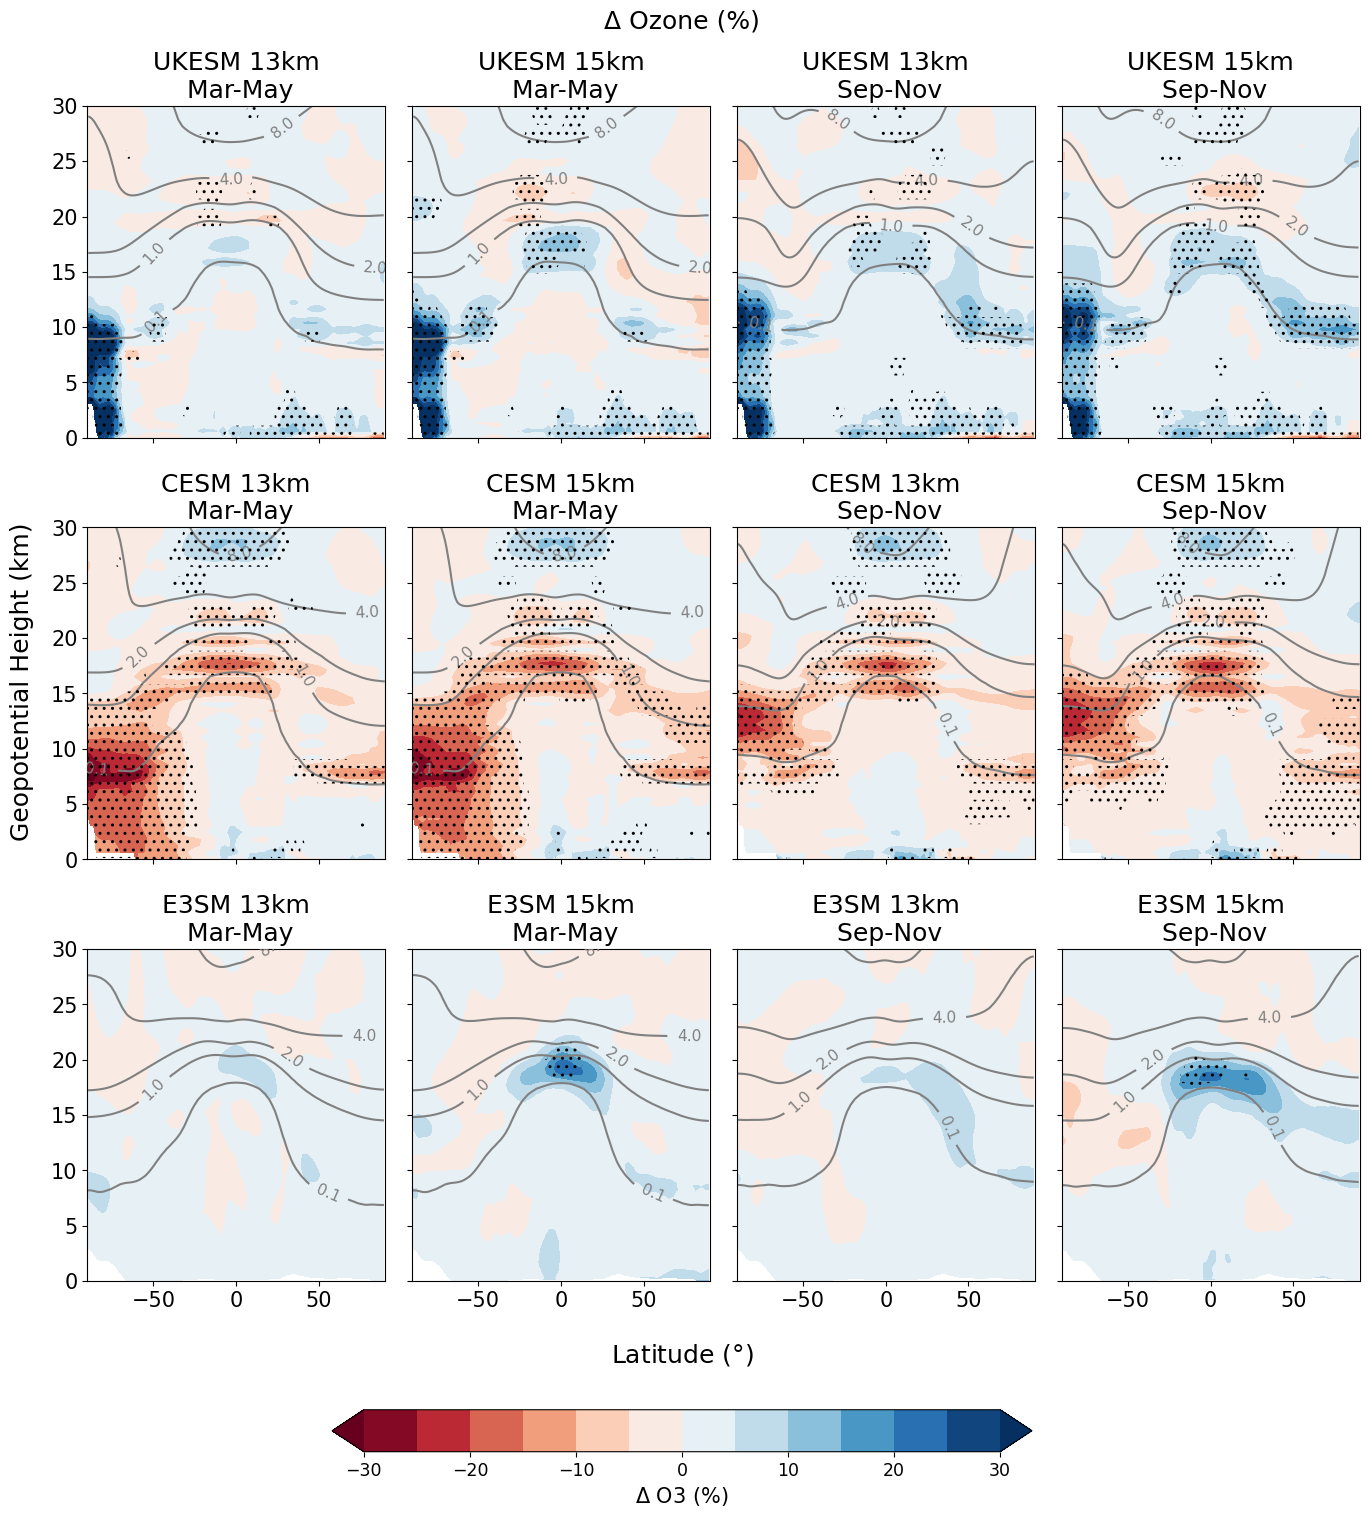

In [26]:
#seasons = {'Jun-Aug': [5,6,7], 'Dec-Feb': [11,0,1]} # note isel not sel, so 0=Jan, 1=Feb etc.
seasons = {'Mar-May': [2, 3, 4], 'Sep-Nov': [8, 9, 10]} # note isel not sel, so 0=Jan, 1=Feb etc.
fig, axs = plt.subplots(3, 4, figsize=(14, 14), sharey=True, sharex=True)


i=0
for model in ['UKESM', 'CESM', 'E3SM']:
    for season in list(seasons.keys()):
        for alt in ['13km', '15km']:
            ax = axs.flatten()[i]
            ds = HiLLA_O3_data[model][alt]
            ds_ref = SSP245_data[model]
            ds['O3_delta_perc'] = 100*(ds['O3'] - ds_ref['O3'])/ds_ref['O3']
            ds = ds.isel(month=seasons[season]).mean('month')
            ds_ref = ds_ref.isel(month=seasons[season]).mean('month')

            
            if model in ['UKESM', 'CESM']:
                lats, Z3s = np.meshgrid(ds['latitude'].values, 0.001*ds['Z3'].values)
                O3_delta_perc_values = ds['O3_delta_perc'].values.T
                O3_background_values = ds_ref['O3'].values.T
            elif model == 'E3SM':
                lats, _ = np.meshgrid(ds['latitude'].values, ds['lev'].values)
                # Y-axis: Geopotential Height (Z3)
                Z3s = 0.001*ds['Z3'].values
                # Z (Contour Data): O3_delta_perc
                O3_delta_perc_values = ds['O3_delta_perc'].values
                O3_background_values = ds_ref['O3'].values
            
            # convert back to molar fraction for UKESM
            if model == 'UKESM':
                O3_background_values = O3_background_values/conversion_VMR_to_MMR
                
            # Plot using contourf: X=lat_2d, Y=Z3_values, Z=O3_delta_perc_values
            # Use a diverging colormap since O3_delta_perc represents a delta/change
            # Set vmin/vmax to be symmetric around zero
            max_abs = np.nanmax(np.abs(O3_delta_perc_values))
            levels = np.linspace(-30, 30, 13)
    
            contour = ax.contourf(
                lats,
                Z3s,
                O3_delta_perc_values,
                levels=levels,
                cmap='RdBu', # Red-Blue reversed diverging colormap
                extend='both'
            )

            lines = ax.contour(
                lats,
                Z3s,
                1E6*O3_background_values,
                #levels=np.arange(0, 10, 1),
                levels=[0.1, 1, 2, 4, 8],
                colors='gray'#cmap='RdBu', # Red-Blue reversed diverging colormap
                #extend='both'
            )

            # sig masks for ukesm, cesm:
            if model in ['UKESM', 'CESM']:
                sig_mask = all_sig_masks[season][model][alt].T
                cs_hatch = ax.contourf(sig_mask['latitude'],0.001*sig_mask['Z3'], sig_mask,
                                        levels=[0, 0.2, 1.2], colors='none',
                                        hatches=[None,'..', '..'],
                                        #hatches = ['//', None, None],
                                        extend='neither', zorder=1000)
            elif model == 'E3SM':
                sig_mask = all_sig_masks[season][model][alt]
                lats, _ = np.meshgrid(sig_mask['latitude'].values, sig_mask['lev'].values)
                # Y-axis: Geopotential Height (Z3)
                Z3s = 0.001*ds['Z3'].values
                # Z (Contour Data): O3_delta_perc
                cs_hatch = ax.contourf(lats, Z3s, sig_mask.values,
                                        levels=[0, 0.2, 1.2], colors='none',
                                        hatches=[None,'..', '..'],
                                        #hatches = ['//', None, None],
                                        extend='neither', zorder=1000)
                
                

            ax.clabel(lines, fontsize=11)
            ax.set_title('{m} {a}\n {s}'.format(m=model, a=alt, s=season))
            ax.set_ylim(0, 30)  # Set y-axis limits to focus on lower altitudes
            i=i+1


cbar_ax1 = fig.add_axes([0.25, -0.05, 0.5, 0.03])
cbar1 = fig.colorbar(contour, cax=cbar_ax1, orientation='horizontal', label='\u0394 O3 ($\%$)')
cbar1.ax.tick_params(labelsize='small')


fig.supylabel('Geopotential Height (km)')
fig.supxlabel('Latitude ($\degree$)')
fig.suptitle('\u0394 Ozone (%)')
plt.tight_layout()
plt.savefig('Figures/Ozone_overview_sig.jpg', dpi=350, bbox_inches='tight')

In [27]:
#### repeat with tropopause heights added: 

## also add E3SM 
def seasonal_time_slice(ds, start_yr_str='2050', end_yr_str='2069'):
    ds = ds.sel(time=slice(start_yr_str, end_yr_str)).groupby('time.month').mean(dim='time')
    return ds
from HiLLA_utils import set_time_to_center_of_bounds
ds_E3SM = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.control.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')
ds_Z3_ssp245_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.control_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_ssp245_E3_mn['lev'] = ds_Z3_ssp245_E3_mn['lev']*100 # convert to Pa


def get_Trop_Z_E3SM(ds_trop_P, ds_Z3):
    TROP_P_as_level = ds_trop_P['TROP_P'].rename('lev')
    return ds_Z3['Z3'].interp(lev=TROP_P_as_level, method='linear')   
    
### the difference between scenario is ngeligible - use ssp245 trop p throughout. 

mean_trop_E = {'Mar-May':0.001*get_Trop_Z_E3SM(ds_E3SM.where(ds_E3SM.time.dt.month.isin(seasons['Mar-May']), drop=True).mean(dim='time'), ds_Z3_ssp245_E3_mn),
                'Sep-Nov':0.001*get_Trop_Z_E3SM(ds_E3SM.where(ds_E3SM.time.dt.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='time'), ds_Z3_ssp245_E3_mn)}



In [75]:
os.listdir()

['ztp_AERmon_UKESM1-0-LL_historical_r1i1p1f2_gn_185001-194912.nc',
 'ztp_AERmon_UKESM1-0-LL_historical_r1i1p1f2_gn_195001-201412.nc']

In [85]:
# for data availability, use end of historical scenario for UKESM and CESM
ds_UKESM = xr.open_dataset('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/AERmon/ztp/gn/latest/ztp_AERmon_UKESM1-0-LL_historical_r1i1p1f2_gn_195001-201412.nc')
ds_UKESM = ds_UKESM.sel(time=slice('1995', '2015')).mean('lon').groupby('time.month').mean('time')
mean_trop_U = {'Mar-May':0.001*ds_UKESM.where(ds_UKESM.month.isin(seasons['Mar-May']), drop=True).mean(dim='month').ztp,
                'Sep-Nov':0.001*ds_UKESM.where(ds_UKESM.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='month').ztp}


ds_CESM = xr.open_dataset('/gws/ssde/j25b/cpom/aduffey/Tropopause/CMIP6/CESM2WACCM/historical/r1i1p1f1/ztp_AERmon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc')
ds_CESM = ds_CESM.sel(time=slice('1995', '2015')).mean('lon').groupby('time.month').mean('time')
mean_trop_C = {'Mar-May':0.001*ds_CESM.where(ds_CESM.month.isin(seasons['Mar-May']), drop=True).mean(dim='month').ztp,
                'Sep-Nov':0.001*ds_CESM.where(ds_CESM.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='month').ztp}


In [78]:
"""
ds_E3SM_13 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.01.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')
ds_Z3_13_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.01_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_13_E3_mn['lev'] = ds_Z3_ssp245_E3_mn['lev']*100 # convert to Pa

ds_E3SM_15 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.04.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')
ds_Z3_15_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.04_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_15_E3_mn['lev'] = ds_Z3_ssp245_E3_mn['lev']*100 # convert to Pa


seasons = {'Mar-May': [2, 3, 4], 'Sep-Nov': [8, 9, 10]} # note isel not sel, so 0=Jan, 1=Feb etc.

mean_trop_E = {'ssp245':{'Mar-May':0.001*get_Trop_Z_E3SM(ds_E3SM.where(ds_E3SM.time.dt.month.isin(seasons['Mar-May']), drop=True).mean(dim='time'), ds_Z3_ssp245_E3_mn),
                         'Sep-Nov':0.001*get_Trop_Z_E3SM(ds_E3SM.where(ds_E3SM.time.dt.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='time'), ds_Z3_ssp245_E3_mn)},
               '13km':{'Mar-May':0.001*get_Trop_Z_E3SM(ds_E3SM_13.where(ds_E3SM_13.time.dt.month.isin(seasons['Mar-May']), drop=True).mean(dim='time'), ds_Z3_13_E3_mn),
                         'Sep-Nov':0.001*get_Trop_Z_E3SM(ds_E3SM_13.where(ds_E3SM_13.time.dt.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='time'), ds_Z3_13_E3_mn)},
               '15km':{'Mar-May':0.001*get_Trop_Z_E3SM(ds_E3SM_15.where(ds_E3SM_15.time.dt.month.isin(seasons['Mar-May']), drop=True).mean(dim='time'), ds_Z3_15_E3_mn),
                         'Sep-Nov':0.001*get_Trop_Z_E3SM(ds_E3SM_15.where(ds_E3SM_15.time.dt.month.isin(seasons['Sep-Nov']), drop=True).mean(dim='time'), ds_Z3_15_E3_mn)},
              }
"""

"\nds_E3SM_13 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.01.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')\nds_Z3_13_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.01_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)\nds_Z3_13_E3_mn['lev'] = ds_Z3_ssp245_E3_mn['lev']*100 # convert to Pa\n\nds_E3SM_15 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.04.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')\nds_Z3_15_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.04_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels

In [86]:
trop_dict = {'UKESM':mean_trop_U,
             'CESM':mean_trop_C,
             'E3SM':mean_trop_E}

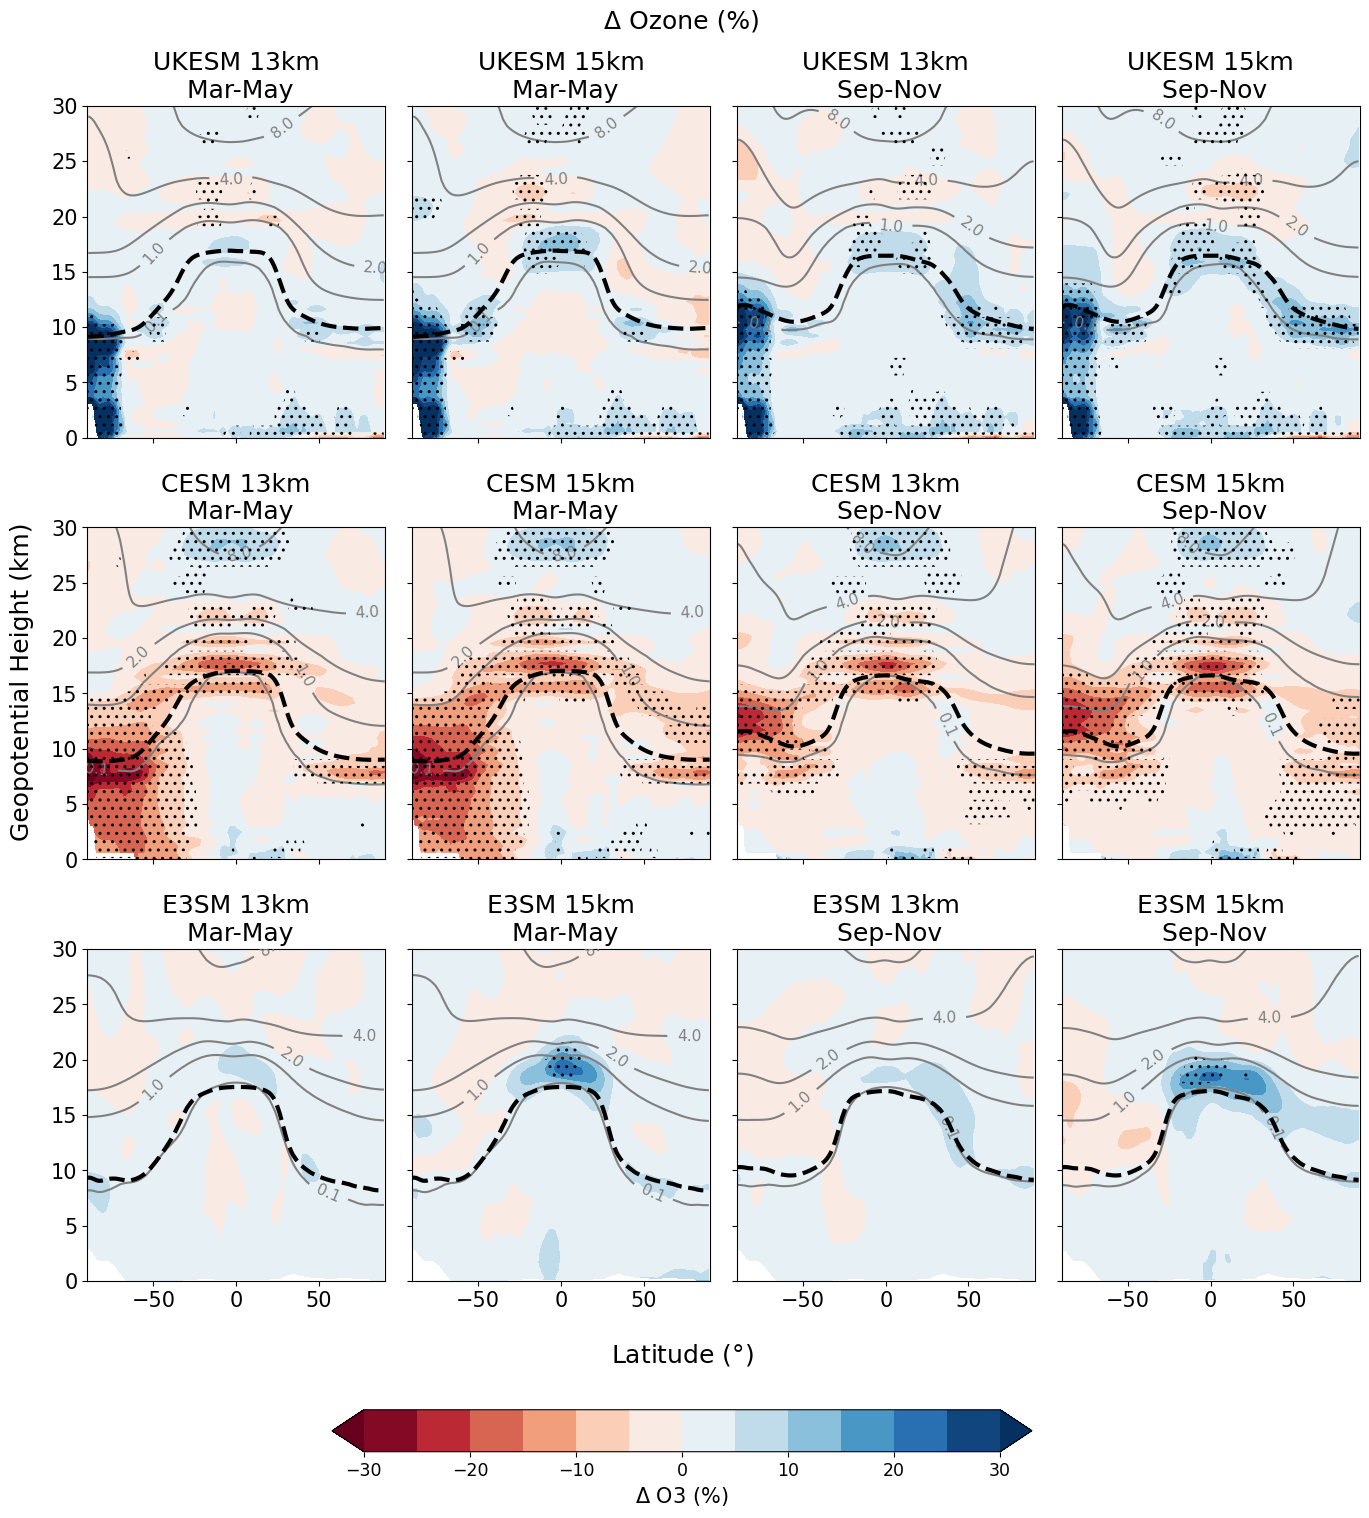

In [87]:
#seasons = {'Jun-Aug': [5,6,7], 'Dec-Feb': [11,0,1]} # note isel not sel, so 0=Jan, 1=Feb etc.
seasons = {'Mar-May': [2, 3, 4], 'Sep-Nov': [8, 9, 10]} # note isel not sel, so 0=Jan, 1=Feb etc.
fig, axs = plt.subplots(3, 4, figsize=(14, 14), sharey=True, sharex=True)


i=0
for model in ['UKESM', 'CESM', 'E3SM']:
    for season in list(seasons.keys()):
        for alt in ['13km', '15km']:
            ax = axs.flatten()[i]
            ds = HiLLA_O3_data[model][alt]
            ds_ref = SSP245_data[model]
            ds['O3_delta_perc'] = 100*(ds['O3'] - ds_ref['O3'])/ds_ref['O3']
            ds = ds.isel(month=seasons[season]).mean('month')
            ds_ref = ds_ref.isel(month=seasons[season]).mean('month')

            
            if model in ['UKESM', 'CESM']:
                lats, Z3s = np.meshgrid(ds['latitude'].values, 0.001*ds['Z3'].values)
                O3_delta_perc_values = ds['O3_delta_perc'].values.T
                O3_background_values = ds_ref['O3'].values.T
            elif model == 'E3SM':
                lats, _ = np.meshgrid(ds['latitude'].values, ds['lev'].values)
                # Y-axis: Geopotential Height (Z3)
                Z3s = 0.001*ds['Z3'].values
                # Z (Contour Data): O3_delta_perc
                O3_delta_perc_values = ds['O3_delta_perc'].values
                O3_background_values = ds_ref['O3'].values
            
            # convert back to molar fraction for UKESM
            if model == 'UKESM':
                O3_background_values = O3_background_values/conversion_VMR_to_MMR
                
            # Plot using contourf: X=lat_2d, Y=Z3_values, Z=O3_delta_perc_values
            # Use a diverging colormap since O3_delta_perc represents a delta/change
            # Set vmin/vmax to be symmetric around zero
            max_abs = np.nanmax(np.abs(O3_delta_perc_values))
            levels = np.linspace(-30, 30, 13)
    
            contour = ax.contourf(
                lats,
                Z3s,
                O3_delta_perc_values,
                levels=levels,
                cmap='RdBu', # Red-Blue reversed diverging colormap
                extend='both'
            )

            lines = ax.contour(
                lats,
                Z3s,
                1E6*O3_background_values,
                #levels=np.arange(0, 10, 1),
                levels=[0.1, 1, 2, 4, 8],
                colors='gray'#cmap='RdBu', # Red-Blue reversed diverging colormap
                #extend='both'
            )

            # sig masks for ukesm, cesm:
            if model in ['UKESM', 'CESM']:
                sig_mask = all_sig_masks[season][model][alt].T
                cs_hatch = ax.contourf(sig_mask['latitude'],0.001*sig_mask['Z3'], sig_mask,
                                        levels=[0, 0.2, 1.2], colors='none',
                                        hatches=[None,'..', '..'],
                                        #hatches = ['//', None, None],
                                        extend='neither', zorder=1000)
            elif model == 'E3SM':
                sig_mask = all_sig_masks[season][model][alt]
                lats, _ = np.meshgrid(sig_mask['latitude'].values, sig_mask['lev'].values)
                # Y-axis: Geopotential Height (Z3)
                Z3s = 0.001*ds['Z3'].values
                # Z (Contour Data): O3_delta_perc
                cs_hatch = ax.contourf(lats, Z3s, sig_mask.values,
                                        levels=[0, 0.2, 1.2], colors='none',
                                        hatches=[None,'..', '..'],
                                        #hatches = ['//', None, None],
                                        extend='neither', zorder=1000)
                
                

            ax.clabel(lines, fontsize=11)
            ax.set_title('{m} {a}\n {s}'.format(m=model, a=alt, s=season))
            ax.set_ylim(0, 30)  # Set y-axis limits to focus on lower altitudes

            trop_da = trop_dict[model][season]
            ax.plot(trop_da.lat, trop_da, lw=3, color='black', zorder=100, ls='--')
            i=i+1


cbar_ax1 = fig.add_axes([0.25, -0.05, 0.5, 0.03])
cbar1 = fig.colorbar(contour, cax=cbar_ax1, orientation='horizontal', label='\u0394 O3 ($\%$)')
cbar1.ax.tick_params(labelsize='small')


### add the tropopause heights




fig.supylabel('Geopotential Height (km)')
fig.supxlabel('Latitude ($\degree$)')
fig.suptitle('\u0394 Ozone (%)')
plt.tight_layout()
plt.savefig('Figures/Ozone_overview_sig_v2.jpg', dpi=350, bbox_inches='tight')

In [ ]:
## also get Dobson units total column ozone (for CESM only, since only CESM has strat het chem on): 

# vertical regridding was not conservative, so if adding up, need to use the og vertical grid data:

#ds_O3_13_plev_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Ozone/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.O3.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'}))#.sel(lev=slice(None, None, -1))
#ds_O3_15_plev_CE = seasonal_time_slice(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'/CESM_data/Ozone/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.O3.203501-206912.nc'), 'time_bnds').mean('lon').rename({'lat':'latitude'}))#.sel(lev=slice(None, None, -1))


## this would need vertical pressure - could do as an extension, but i don't have the data from walker to do it now. 


In [ ]:
os.listdir(path_archive+'E3SM_data/regridded/TROP_P/')